# Figuras de resultados — 16S, 3xTg-AD + Qifuyin (PRJNA1424173)

Este notebook toma los exportes de QIIME2 (`fig_export/`) y produce las cuatro figuras
de resultados, en `.pdf` vectorial y `.png` a 300 dpi.

**División de trabajo:** QIIME2 calculó (rarefacción a 43.186, UniFrac, Faith PD,
PERMANOVA); acá solo se dibuja. Ningún número se recalcula.

**OJO: el PCoA que se dibuja acá es el que QIIME2 ya calculó** (`ordination.txt`),
no uno nuevo. Los ejes y los porcentajes coinciden exactamente con los `*_emperor.qzv`.

In [1]:
import os, sys
import numpy as np, pandas as pd
import matplotlib as mpl, matplotlib.pyplot as plt
from matplotlib.patches import Ellipse

sys.path.append(os.getcwd())          # para importar figuras_16s.py del directorio actual
import figuras_16s as f16

BASE   = "fig_export"                 # carpeta que salio del tar
SALIDA = "figuras"; os.makedirs(SALIDA, exist_ok=True)

GRUPOS = ["Con", "Mod", "QFY"]
PAL    = {"Con": "#0173B2", "Mod": "#DE8F05", "QFY": "#029E73"}   # segura para daltonismo
GRIS   = "#8C8C8C"                    # reservado para la categoria "Otros"

# --- estilo de figura: una sola vez, vale para todo el notebook ---
mpl.rcParams.update({
    "figure.dpi": 120, "savefig.dpi": 300, "savefig.bbox": "tight",
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica Neue", "Helvetica", "Arial", "DejaVu Sans"],
    "font.size": 8, "axes.labelsize": 8, "axes.titlesize": 8,
    "xtick.labelsize": 7, "ytick.labelsize": 7, "legend.fontsize": 7,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.linewidth": 0.8, "xtick.major.width": 0.8, "ytick.major.width": 0.8,
    "xtick.direction": "out", "ytick.direction": "out",
    "axes.titlelocation": "left", "axes.titlepad": 6,
    "pdf.fonttype": 42, "ps.fonttype": 42,   # texto editable en Illustrator/Inkscape
})
RNG = np.random.default_rng(0)        # semilla fija -> el jitter no cambia entre corridas

## 1. Cargar y verificar

Los cinco lectores de `figuras_16s.py` resuelven las trampas de formato de QIIME2:
la línea de comentario del `biom`, la fila `#q2:types`, el linaje pegado en una sola
columna, y el `ordination.txt`. Las verificaciones de abajo son las que importan,
si alguna falla, el problema está en el exporte y no hay que seguir.

In [2]:
tabla = f16.leer_tabla_asv(f"{BASE}/asv_table.tsv")      # conteos CRUDOS (no rarificados)
tax   = f16.leer_taxonomia(f"{BASE}/taxonomy.tsv")
md_   = f16.leer_metadata(f"{BASE}/metadata.tsv")

# la tabla manda: se une DESDE la tabla hacia la taxonomia, nunca al reves
assert tabla.columns.isin(md_.index).all(),      "hay muestras sin metadata"
assert tabla.index.isin(tax.index).all(),        "hay ASVs sin taxonomia"
assert not md_.index.astype(str).str.startswith("#").any(), "quedo #q2:types en la metadata"

print("ASVs:", tabla.shape[0], "| muestras:", tabla.shape[1], "| lecturas:", int(tabla.values.sum()))
print("n por grupo:", md_.grupo.value_counts().reindex(GRUPOS).to_dict())
print("profundidad por muestra: min", int(tabla.sum().min()), "max", int(tabla.sum().max()))
print("sin familia asignada:", f"{tax.reindex(tabla.index).familia.isna().mean()*100:.1f} %")

ASVs: 2872 | muestras: 42 | lecturas: 2559131
n por grupo: {'Con': 14, 'Mod': 14, 'QFY': 14}
profundidad por muestra: min 43186 max 69426
sin familia asignada: 1.0 %


In [3]:
# Abundancia relativa. ORDEN: relativizar por muestra PRIMERO, colapsar despues.
# Al reves (sumar conteos crudos y relativizar al final) las muestras mas profundas dominan.
rel_f = f16.abundancia_relativa(tabla, tax, "familia")
rel_p = f16.abundancia_relativa(tabla, tax, "phylum")

mg_f = f16.top_con_otros(f16.media_por_grupo(rel_f, md_) * 100, n=10)
mg_p = f16.top_con_otros(f16.media_por_grupo(rel_p, md_) * 100, n=6)

assert np.allclose(rel_f.sum(axis=0), 1), "las abundancias relativas no suman 1 por muestra"
assert np.allclose(mg_f.sum(axis=0), 100), "las barras apiladas no cierran en 100 %"
mg_f.round(2)

grupo,Con,Mod,QFY
Muribaculaceae,33.40,11.85,26.57
Lachnospiraceae,16.04,12.46,11.36
Lactobacillaceae,7.89,14.27,15.57
Prevotellaceae,12.18,7.51,12.66
Bacteroidaceae,5.32,9.07,4.85
Erysipelotrichaceae,4.39,7.85,4.72
Streptococcaceae,0.06,6.05,2.53
Helicobacteraceae,2.13,4.65,2.87
Enterobacteriaceae,1.04,3.95,1.20
Acidaminococcaceae,1.47,3.13,1.41


## 2. Funciones de dibujo

Tres funciones, definidas una vez y reusadas. El código está a la vista a propósito:
los colores, tamaños y anotaciones se tocan acá.

In [4]:
def barras_apiladas(ax, m, titulo, cmap):
    """Barras apiladas de composicion. 'Otros' siempre gris y siempre arriba."""
    cols = plt.get_cmap(cmap)(np.linspace(0.08, 0.92, len(m)))
    if m.index[-1] == "Otros":
        cols[-1] = mpl.colors.to_rgba(GRIS)
    abajo = np.zeros(m.shape[1])
    for (nom, fila), c in zip(m.iterrows(), cols):
        ax.bar(m.columns.astype(str), fila.values, bottom=abajo, color=c,
               edgecolor="white", linewidth=0.6, width=0.62,
               label=f"$\\it{{{nom}}}$" if nom != "Otros" else nom)   # taxones en cursiva
        abajo += fila.values
    ax.set_ylim(0, 100); ax.set_ylabel("Abundancia relativa media (%)")
    ax.set_title(titulo); ax.margins(x=0.12)
    h, l = ax.get_legend_handles_labels()
    ax.legend(h[::-1], l[::-1], frameon=False, loc="center left",   # leyenda en el orden del apilado
              bbox_to_anchor=(1.02, 0.5), handlelength=0.9, labelspacing=0.3)


In [5]:
def strip_mediana(ax, datos, jitter=0.085, s=16):
    """Puntos individuales + barra de mediana. Muestra n y dispersion real,
    que un boxplot con n=14 esconde."""
    for i, g in enumerate(GRUPOS):
        v = np.asarray(datos[g], dtype=float)
        ax.scatter(i + RNG.normal(0, jitter, len(v)), v, s=s, color=PAL[g], alpha=0.75,
                   linewidths=0.4, edgecolors="white", zorder=3, clip_on=False)
        ax.hlines(np.median(v), i - 0.26, i + 0.26, color=PAL[g], lw=2.0, zorder=4)
    ax.set_xticks(range(len(GRUPOS))); ax.set_xticklabels(GRUPOS)
    ax.set_xlim(-0.5, len(GRUPOS) - 0.5)


In [6]:
def bracket(ax, i, j, q, alt=0.06, marca=""):
    """Corchete de significancia entre dos grupos. Se anota el q, nunca el p.

    OJO: con q muy chico, f"{q:.3f}" imprime "0,000", que no es un valor.
         Por debajo de 0,001 se escribe "q < 0,001", que es lo correcto.
    `marca` es para la daga de los resultados no robustos (ver Figura 2).
    """
    y0, y1 = ax.get_ylim(); h = y1 - y0
    y = y1 + h * 0.02
    etq = ("q < 0,001" if q < 0.001 else f"q = {q:.3f}".replace(".", ",")) + marca
    ax.plot([i, i, j, j], [y, y + h*alt*0.35, y + h*alt*0.35, y], lw=0.8, color="0.25", clip_on=False)
    ax.text((i + j)/2, y + h*alt*0.42, etq,
            ha="center", va="bottom", fontsize=7, color="0.15")
    ax.set_ylim(y0, y1 + h*alt*1.1)


In [7]:
def guardar(fig, nombre):
    for ext in ("pdf", "png"):
        fig.savefig(f"{SALIDA}/{nombre}.{ext}")
    print("guardado:", nombre)


## Figura 1: Composición por grupo

Panel **a** filo, panel **b** familia. Es la figura descriptiva que va primero en
resultados: no tiene test, muestra la estructura.

guardado: fig1_composicion


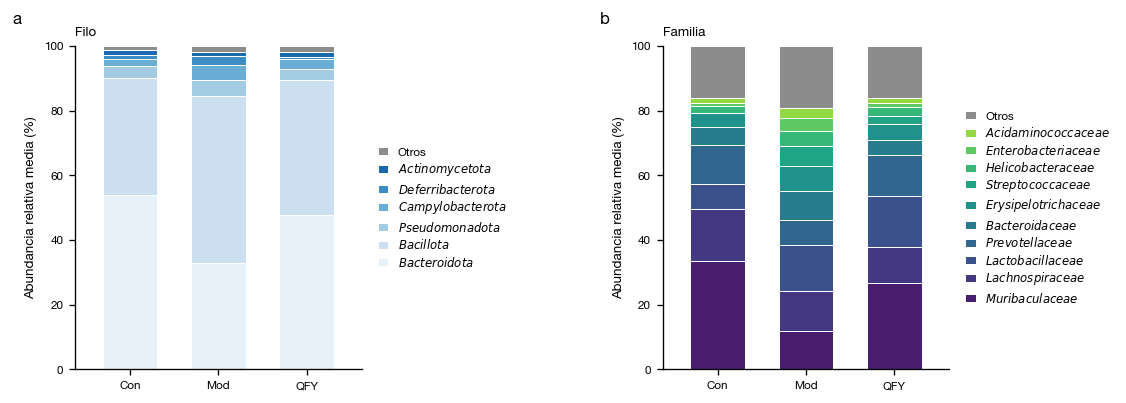

In [8]:
fig1, axes = plt.subplots(1, 2, figsize=(9.4, 3.5), gridspec_kw=dict(wspace=1.05))
barras_apiladas(axes[0], mg_p, "Filo", "Blues")
barras_apiladas(axes[1], mg_f, "Familia", "viridis")
for ax, L in zip(axes, "ab"):
    ax.text(-0.22, 1.06, L, transform=ax.transAxes, fontsize=10, fontweight="bold", va="bottom")
guardar(fig1, "fig1_composicion")

## Figura 2: Familias dominantes, muestra por muestra

Lo que la Figura 1 esconde: la dispersión. Cada punto es un ratón.

**OJO: acá no hay q-valores todavía.** Estas son medias y medianas descriptivas.
El q sale de ANCOM-BC (P9), que trabaja en espacio composicional. No corras un
Kruskal-Wallis por familia sobre estos porcentajes: son datos composicionales
(suman 1) y el test da falsos positivos.

guardado: fig2_familias_dominantes


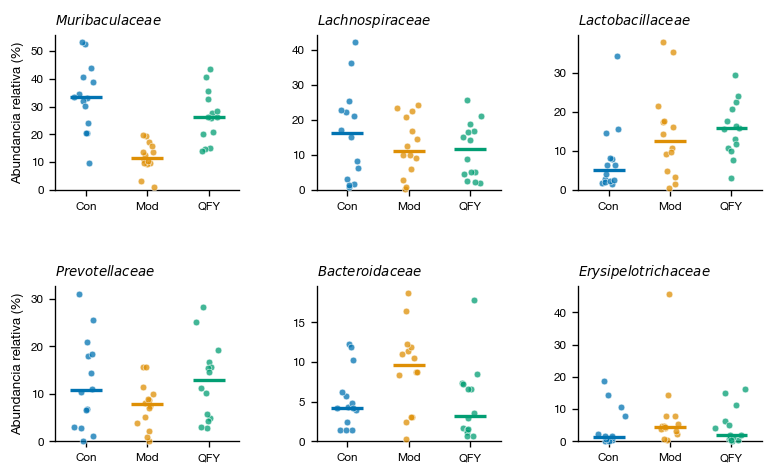

In [9]:
FAMS = [f for f in mg_f.index if f != "Otros"][:6]

fig2, axes = plt.subplots(2, 3, figsize=(7.6, 4.4), gridspec_kw=dict(hspace=0.62, wspace=0.42))
for ax, fam in zip(axes.ravel(), FAMS):
    datos = {g: (rel_f.loc[fam, md_.index[md_.grupo == g]] * 100).values for g in GRUPOS}
    strip_mediana(ax, datos)
    ax.set_title(f"$\\it{{{fam}}}$"); ax.set_ylim(bottom=0)
for ax in axes[:, 0]:
    ax.set_ylabel("Abundancia relativa (%)")
guardar(fig2, "fig2_familias_dominantes")

## Figura 3: Alfa diversidad

Reemplaza los cuatro `*-group-significance.qzv` de P6 por un panel único.

Los q-valores están **escritos a mano** en `ALFA`, copiados de las tablas de
Kruskal-Wallis de los `.qzv`. QIIME2 no los exporta a `.tsv`, así que es la única
parte del notebook que no se recalcula desde archivo — si cambia la rarefacción,
hay que actualizarlos acá.

guardado: fig3_alfa_diversidad


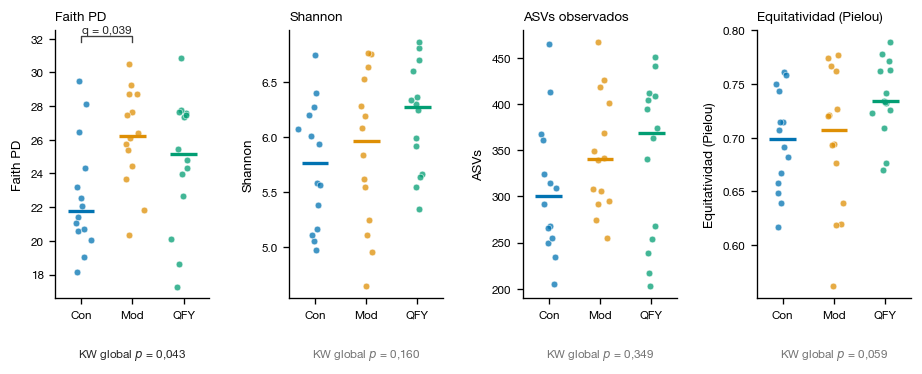

In [10]:
# metrica, etiqueta del eje, p global de Kruskal-Wallis, [(i, j, q) de los pares significativos]
ALFA = [
    ("faith_pd",          "Faith PD",               0.0434, [(0, 1, 0.0393)]),  # Con vs Mod
    ("shannon",           "Shannon",                0.1595, []),
    ("observed_features", "ASVs observados",        0.3495, []),
    ("evenness",          "Equitatividad (Pielou)", 0.0585, []),
]

fig3, axes = plt.subplots(1, 4, figsize=(9.2, 2.9), gridspec_kw=dict(wspace=0.52))
for ax, (m, nom, p, pares) in zip(axes, ALFA):
    s = f16.leer_alfa(f"{BASE}/alfa_{m}/alpha-diversity.tsv")
    assert s.index.isin(md_.index).all(), f"{m}: muestras que no estan en la metadata"
    strip_mediana(ax, {g: s[md_.index[md_.grupo == g]].values for g in GRUPOS})
    ax.set_title(nom); ax.set_ylabel("ASVs" if m == "observed_features" else nom)
    ax.annotate(f"KW global $p$ = {p:.3f}".replace(".", ","), xy=(0.5, -0.22),
                xycoords="axes fraction", ha="center", fontsize=7,
                color="0.15" if p < 0.05 else "0.45")   # gris si no es significativo
    for i, j, q in pares:
        bracket(ax, i, j, q)
guardar(fig3, "fig3_alfa_diversidad")

## Figura 4: PCoA de UniFrac

Reemplaza Emperor, que es interactivo y no se puede publicar. Mismos ejes, mismos
porcentajes, mismas coordenadas.

Las elipses son de **95 % de confianza** (χ² con 2 gl → factor 5,991), no de
desviación estándar: describen dónde estaría el centroide del grupo, no dónde
están los puntos.

**OJO — el eje tiene aspecto 1:1 a propósito** (`set_aspect("equal")`). En una
ordenación las unidades de los dos ejes son las mismas; si se estira un eje, las
distancias entre puntos dejan de ser comparables y el gráfico miente.

In [11]:
# PERMANOVA de beta-group-significance (global + de a pares). Copiados de los .qzv.
# p = 0,001 es el piso con 999 permutaciones: significa "menor que", no un valor exacto.
BETA = {
    "unweighted_unifrac": dict(
        titulo="UniFrac no ponderada", F=2.848, p=0.001,
        pares=[("Con", "Mod", 3.810, 0.0015), ("Con", "QFY", 3.052, 0.0015),
               ("Mod", "QFY", 1.872, 0.0140)]),
    "weighted_unifrac": dict(
        titulo="UniFrac ponderada", F=5.710, p=0.001,
        pares=[("Con", "Mod", 8.972, 0.0015), ("Con", "QFY", 2.613, 0.0260),
               ("Mod", "QFY", 5.009, 0.0015)]),
}


Los números de arriba se editan solos, sin tocar el dibujo.
El de abajo es el código de la figura.


guardado: fig4_pcoa_unifrac
             metrica grupo_1 grupo_2  pseudo_F      q
UniFrac no ponderada     Con     Mod     3.810 0.0015
UniFrac no ponderada     Con     QFY     3.052 0.0015
UniFrac no ponderada     Mod     QFY     1.872 0.0140
   UniFrac ponderada     Con     Mod     8.972 0.0015
   UniFrac ponderada     Con     QFY     2.613 0.0260
   UniFrac ponderada     Mod     QFY     5.009 0.0015


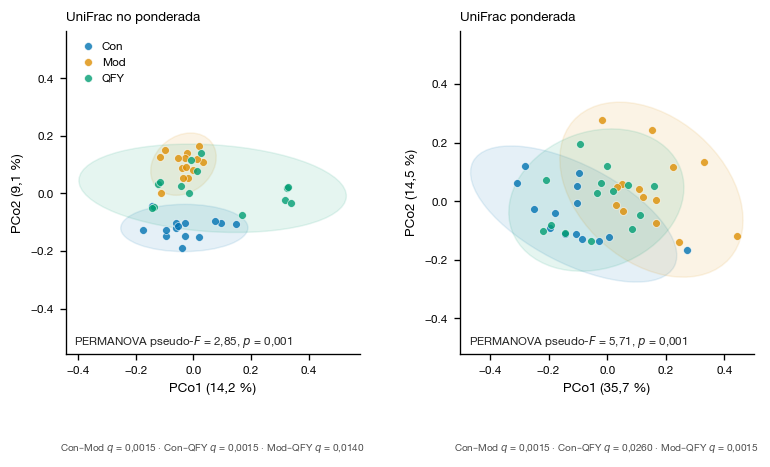

In [12]:
fig4, axes = plt.subplots(1, 2, figsize=(7.4, 3.5), gridspec_kw=dict(wspace=0.34))
for ax, (nom, info) in zip(axes, BETA.items()):
    co_, pe = f16.leer_ordinacion(f"{BASE}/pcoa_{nom}/ordination.txt")
    for g in GRUPOS:
        sub = co_.loc[md_.index[md_.grupo == g]]
        ax.scatter(sub.PC1, sub.PC2, s=22, color=PAL[g], alpha=0.8, linewidths=0.4,
                   edgecolors="white", label=g, zorder=3)
        w, v = np.linalg.eigh(np.cov(sub.PC1, sub.PC2))
        ax.add_patch(Ellipse(sub[["PC1", "PC2"]].mean().values,
                             *(2 * np.sqrt(w[::-1] * 5.991)),
                             angle=np.degrees(np.arctan2(*v[:, -1][::-1])),
                             facecolor=PAL[g], alpha=0.10, edgecolor=PAL[g], lw=0.9, zorder=1))
    ax.set_xlabel(f"PCo1 ({pe.PC1*100:.1f} %)".replace(".", ","))
    ax.set_ylabel(f"PCo2 ({pe.PC2*100:.1f} %)".replace(".", ","))
    ax.set_title(info["titulo"])
    ax.set_aspect("equal", adjustable="datalim")
    # global: es UN test, va p (no hay nada que corregir)
    ax.annotate(f"PERMANOVA pseudo-$F$ = {info['F']:.2f}, $p$ = 0,001".replace(".", ",", 1),
                xy=(0.03, 0.03), xycoords="axes fraction", fontsize=7, color="0.15")
    # de a pares: son 3 tests, va q (corregido por FDR)
    ax.annotate(" · ".join(f"{a}–{b} $q$ = {q:.4f}".replace(".", ",") for a, b, _, q in info["pares"]),
                xy=(0.5, -0.30), xycoords="axes fraction", ha="center", fontsize=6, color="0.30")
axes[0].legend(frameon=False, loc="upper left", handletextpad=0.2)
guardar(fig4, "fig4_pcoa_unifrac")

# tabla del suplementario con los 6 tests de a pares
pw = pd.DataFrame([(info["titulo"], a, b, F, q) for info in BETA.values()
                   for a, b, F, q in info["pares"]],
                  columns=["metrica", "grupo_1", "grupo_2", "pseudo_F", "q"])
pw.to_csv("figuras/tablaS2_permanova_pares.csv", index=False)
print(pw.to_string(index=False))


## Figura 5: Razón Bacillota / Bacteroidota (F/B)

El descriptor clásico de la literatura, para poder comparar con otros papers.
Un punto por ratón, eje en log, la línea punteada es el 1:1.

**OJO: los nombres son los nuevos.** SILVA 138+ renombró *Firmicutes* → *Bacillota*
y *Bacteroidetes* → *Bacteroidota*: son los mismos filos. Y *Bacteroides* (sin `-ota`)
es un **género**, no el filo — "Firmicutes/Bacteroides" es un error de nivel taxonómico.

**OJO: esto es descriptivo, no un biomarcador.** Es una razón entre dos partes de un
total que suma 100 %, así que si una sube la otra baja por construcción, y el valor
absoluto no es comparable entre estudios (depende de la base de datos y de la región
amplificada). Sirve para situar el dataset frente a la literatura; el resultado
estadístico de composición es el PERMANOVA (Figura 4) y ANCOM-BC (P9).

El test de esta figura viene comentado a propósito: QIIME2 no calcula razones entre
filos, así que si se destapa, el p es Kruskal-Wallis **calculado en Python** y hay que
declararlo así en la leyenda.

guardado: fig5_ratio_FB
       mediana   min   max
grupo                     
Con       0.60  0.26  2.43
Mod       1.36  0.87  9.89
QFY       0.88  0.47  1.87


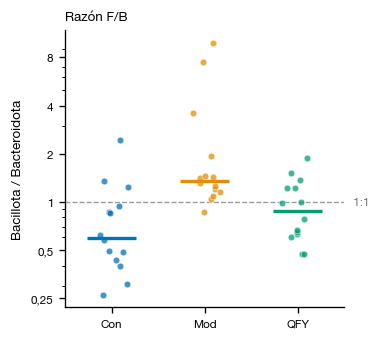

In [13]:
# --- Figura 5: razon Bacillota / Bacteroidota (el clasico "F/B ratio") ---
# OJO con los nombres: SILVA 138+ renombro Firmicutes -> Bacillota y Bacteroidetes -> Bacteroidota.
# Son los mismos filos, nombre nuevo. Se aceptan las dos grafias por si cambias de base.
ALIAS = {"Bacillota": ["Bacillota", "Firmicutes"],
         "Bacteroidota": ["Bacteroidota", "Bacteroidetes"]}
filo = {}
for k, opciones in ALIAS.items():
    hit = [o for o in opciones if o in rel_p.index]
    assert hit, f"no encuentro {k} en rel_p; filos disponibles: {list(rel_p.index)}"
    filo[k] = rel_p.loc[hit[0]]

# La razon se calcula por MUESTRA y despues se resume. Al reves (razon entre las medias
# del grupo) se pierde la dispersion y un animal extremo se disfraza de efecto.
assert (filo["Bacteroidota"] > 0).all(), "hay muestras con Bacteroidota = 0, la razon es infinita"
fb = (filo["Bacillota"] / filo["Bacteroidota"]).rename("FB")

fig5, ax = plt.subplots(figsize=(3.0, 3.0))
strip_mediana(ax, {g: fb[md_.index[md_.grupo == g]].values for g in GRUPOS})
ax.set_yscale("log")                  # la razon es multiplicativa: 0,5 y 2 estan igual de lejos de 1
ax.axhline(1, ls="--", lw=0.8, color="0.6", zorder=1)
ax.yaxis.set_major_locator(mpl.ticker.FixedLocator([0.25, 0.5, 1, 2, 4, 8]))
ax.yaxis.set_minor_formatter(mpl.ticker.NullFormatter())
ax.yaxis.set_major_formatter(mpl.ticker.FuncFormatter(lambda v, p: f"{v:g}".replace(".", ",")))
ax.set_ylabel("Bacillota / Bacteroidota")
ax.set_title("Razón F/B")
ax.text(1.02, 1, " 1:1", transform=ax.get_yaxis_transform(), va="center", fontsize=7, color="0.45")
guardar(fig5, "fig5_ratio_FB")

# resumen por grupo: mediana y rango, los numeros que van al texto
print(fb.groupby(md_.grupo, observed=True).agg(mediana="median", min="min", max="max")
        .reindex(GRUPOS).round(2))

# Test opcional. NO viene de QIIME2: esto si se calcula en Python, asi que hay que declararlo
# como tal en la leyenda. Necesita scipy -> conda install -n figuras16s scipy
# from scipy.stats import kruskal
# print("Kruskal-Wallis p =", kruskal(*[fb[md_.index[md_.grupo == g]] for g in GRUPOS]).pvalue)

## 3. Tabla para el suplementario

Las medias por grupo que están detrás de la Figura 1, en un `.csv` citable.

In [14]:
sup = (f16.media_por_grupo(rel_f, md_) * 100).round(3)
sup.insert(0, "n_ASVs", tax.reindex(tabla.index).groupby("familia").size().reindex(sup.index))
sup = sup.sort_values("Con", ascending=False)
sup.to_csv(f"{SALIDA}/tablaS1_familias_por_grupo.csv")
print(sup.shape); sup.head(12)

(156, 4)


grupo,n_ASVs,Con,Mod,QFY
Muribaculaceae,385.0,33.404,11.846,26.568
Lachnospiraceae,709.0,16.037,12.464,11.362
Prevotellaceae,54.0,12.181,7.514,12.664
Lactobacillaceae,76.0,7.890,14.268,15.570
Bacteroidaceae,66.0,5.318,9.066,4.854
Erysipelotrichaceae,98.0,4.392,7.849,4.724
Sutterellaceae,36.0,2.631,1.039,2.182
Ruminococcaceae,153.0,2.567,2.409,1.589
Helicobacteraceae,20.0,2.129,4.652,2.871
Acidaminococcaceae,10.0,1.470,3.127,1.409


## 4. Hueco para P9 (ANCOM-BC)

Cuando se corra la abundancia diferencial, el resultado de QIIME2 exporta a `.tsv` y
entra acá: filtrar por `q < 0,05`, y volver a dibujar la Figura 2 con el corchete
de significancia sobre las familias que pasaron. Es el mismo `bracket()` de arriba.

**Antes de reportar una familia como diferencial, convertir su % a lecturas:**

    f16.lecturas_equivalentes(pct, 2559131/42)   # ~60.932 lecturas/muestra

Bajo ~10 lecturas por muestra la diferencia es azar de muestreo, por más que el q
sea chico. Es la regla que salió de los claims traza del paper.

## Figura 2 (definitiva): Familias dominantes con los q de ANCOM-BC2

Vuelve a dibujar la Figura 2, ahora con los q-values reales del P9 sobre los corchetes. Esta es laversión definitiva, la de arriba era el panel sin estadística.

**OJO 1**: se anota `q`, no `p`. El `q`que sale de ANCOM-BC2, que ya corrige por el número de familias testeadas (BH).

**OJO 2:** solo se dibuja el corchete si q < 0,05. Un corchete con q = 0,04 no informa nada y ensucia el panel.

**OJO 3**: una familia que no aparece en la tabla de ANCOM-BC2 no es una familia sin efecto, es una familia que el filtro de prevalencia (10%) no testeó. El panel la muestra igual, pero sin corchete. La lista imprime la celda.

guardado: fig2_familias_dominantes
tests por contraste:
             n     q_min
contraste               
Mod vs Con  54  0.000016
QFY vs Mod  54  0.050632

familias del panel sin test (prevalencia < 10 %): ninguna
familias del panel con nombre duplicado (sin corchete): ninguna

significativas (q < 0,05): 9 | robustas: 2
              familia  contraste       lfc        q  diff_robust
     Streptococcaceae Mod vs Con  3.981633 0.000016         True
Peptostreptococcaceae Mod vs Con  2.794429 0.010218        False
       Peptococcaceae Mod vs Con -1.910145 0.012394        False
       Muribaculaceae Mod vs Con -1.601074 0.016463        False
      Brachyspiraceae Mod vs Con -2.241262 0.016463         True
       Sutterellaceae Mod vs Con -1.609472 0.032822        False
         Atopobiaceae Mod vs Con -1.805321 0.032822        False
    Staphylococcaceae Mod vs Con -1.843479 0.034256        False
   Acholeplasmataceae Mod vs Con -2.252060 0.041472        False

Las marcadas con dagger en

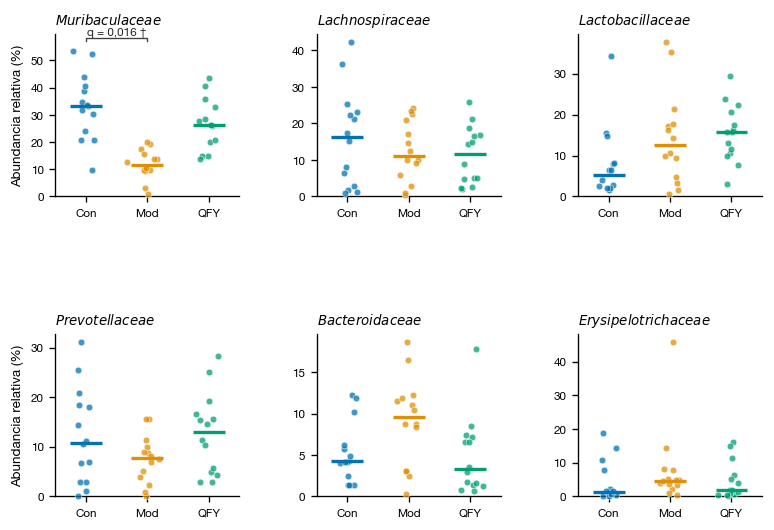

In [15]:
# --- Figura 2 con los q de ANCOM-BC2 (P9) ---
# Dos corridas porque ANCOM-BC2 solo contrasta contra su referencia:
#   ref Con -> "Mod vs Con"  (el efecto del modelo)
#   ref Mod -> "QFY vs Mod"  (el efecto del tratamiento)
da_con = f16.leer_ancombc2(f"{BASE}/ancombc2_export_Con")
da_mod = f16.leer_ancombc2(f"{BASE}/ancombc2_export_Mod")

# De la corrida B se usa SOLO QFY vs Mod: el "Con vs Mod" es el mismo de la
# corrida A con el signo invertido, no es un test nuevo y no se cuenta dos veces.
da = pd.concat([da_con[da_con.contraste == "Mod vs Con"],
                da_mod[da_mod.contraste == "QFY vs Mod"]], ignore_index=True)
da.to_csv("tablaS3_ancombc2_familias.csv", index=False)

# q y robustez por (familia, contraste), como diccionario.
# OJO: un mismo nombre de familia puede venir de DOS linajes distintos (pasa con
# los que quedan sin nombre de orden). En ese caso el panel de la figura es la
# suma de los dos, pero el test es de cada uno por separado: no son comparables,
# asi que esas familias quedan SIN corchete y se listan aparte.
agg = (da.groupby(["familia", "contraste"])
         .agg(n=("q", "size"), q=("q", "min"), rob=("diff_robust", "all"))
         .reset_index())
ambiguas = agg[agg.n > 1]
Q   = {(r.familia, r.contraste): r.q   for r in agg.itertuples() if r.n == 1}
ROB = {(r.familia, r.contraste): r.rob for r in agg.itertuples() if r.n == 1}
PARES = [("Mod vs Con", 0, 1), ("QFY vs Mod", 1, 2)]   # posiciones x de Con/Mod/QFY

fig2, axes = plt.subplots(2, 3, figsize=(7.6, 5.0), gridspec_kw=dict(hspace=0.85, wspace=0.42))
for ax, fam in zip(axes.ravel(), FAMS):
    datos = {g: (rel_f.loc[fam, md_.index[md_.grupo == g]] * 100).values for g in GRUPOS}
    strip_mediana(ax, datos)
    ax.set_title(f"$\\it{{{fam}}}$"); ax.set_ylim(bottom=0)
    for contraste, i, j in PARES:
        q = Q.get((fam, contraste))
        if q is not None and q < 0.05:            # solo se anota lo significativo
            # la daga marca lo que NO paso el analisis de sensibilidad
            bracket(ax, i, j, q, marca="" if ROB[(fam, contraste)] else " \u2020")
for ax in axes[:, 0]:
    ax.set_ylabel("Abundancia relativa (%)")
guardar(fig2, "fig2_familias_dominantes")

# --- controles que hay que leer antes de escribir el pie de figura -------------
print("tests por contraste:")
print(da.groupby("contraste").agg(n=("q", "size"), q_min=("q", "min")).to_string())

fuera = [f for f in FAMS if f not in set(da.familia)]
print("\nfamilias del panel sin test (prevalencia < 10 %):", fuera or "ninguna")
print("familias del panel con nombre duplicado (sin corchete):",
      [f for f in FAMS if f in set(ambiguas.familia)] or "ninguna")

sig = da[da.q < 0.05].sort_values("q")
print("\nsignificativas (q < 0,05):", len(sig),
      "| robustas:", int(sig.diff_robust.astype(bool).sum()))
print(sig[["familia", "contraste", "lfc", "q", "diff_robust"]].to_string(index=False))
print("\nLas marcadas con dagger en la figura son las de diff_robust = False.")

guardado: fig6_rutas_predichas
rutas testeadas por contraste:
              n     q_min
contraste                
Mod vs Con  424  0.002778
QFY vs Mod  424  0.012226

significativas (q < 0,05): 71 | robustas: 16 | dibujadas: 15
contraste
Mod vs Con    67
QFY vs Mod     4


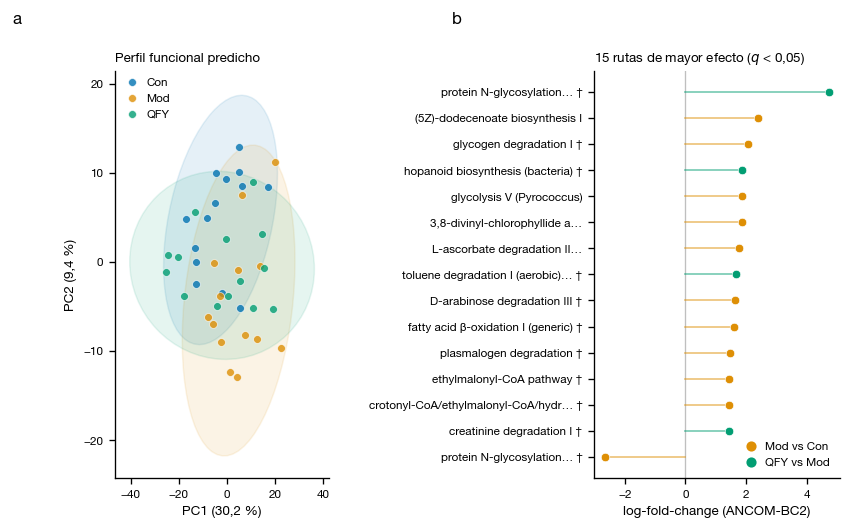

In [20]:
# --- Figura 6: rutas metabolicas predichas (PICRUSt2 + ANCOM-BC2, P10) ---
import html
# Misma logica que la Figura 2: dos corridas, y de la segunda solo el contraste
# del tratamiento, porque "Con vs Mod" es el de la primera con el signo invertido.
ab_r, desc_r = f16.leer_rutas_abundancia(f"{BASE}/path_abun_unstrat_descrip.tsv.gz")
da_r = pd.concat([f16.leer_ancombc2_rutas(f"{BASE}/rutas_export_Con").query("contraste == 'Mod vs Con'"),
                  f16.leer_ancombc2_rutas(f"{BASE}/rutas_export_Mod").query("contraste == 'QFY vs Mod'")],
                 ignore_index=True)
da_r["descripcion"] = da_r["ruta"].map(desc_r)
da_r.to_csv(f"{SALIDA}/tablaS4_rutas_ancombc2.csv", index=False)

COL_C = {"Mod vs Con": PAL["Mod"], "QFY vs Mod": PAL["QFY"]}   # color = grupo testeado
TOPE  = 15                                                      # filas del panel b

fig6 = plt.figure(figsize=(7.8, 4.4))
# wspace ancho a proposito: las etiquetas de las rutas van en el hueco del medio
gs   = fig6.add_gridspec(1, 2, width_ratios=[1, 1.15], wspace=1.15)

# --- a) PCA de los perfiles funcionales (CLR) ---
ax = fig6.add_subplot(gs[0, 0])
X  = f16.clr_muestras(ab_r).loc[md_.index]
Xc = X - X.mean(axis=0)
U, S, Vt = np.linalg.svd(Xc.values, full_matrices=False)
pc = pd.DataFrame(U[:, :2] * S[:2], index=X.index, columns=["PC1", "PC2"])
var = (S**2 / (S**2).sum())[:2] * 100
for g in GRUPOS:
    sub = pc.loc[md_.index[md_.grupo == g]]
    ax.scatter(sub.PC1, sub.PC2, s=22, color=PAL[g], alpha=0.8, linewidths=0.4,
               edgecolors="white", label=g, zorder=3)
    w, v = np.linalg.eigh(np.cov(sub.PC1, sub.PC2))
    ax.add_patch(Ellipse(sub[["PC1", "PC2"]].mean().values,
                         *(2 * np.sqrt(w[::-1] * 5.991)),
                         angle=np.degrees(np.arctan2(*v[:, -1][::-1])),
                         facecolor=PAL[g], alpha=0.10, edgecolor=PAL[g], lw=0.9, zorder=1))
ax.set_xlabel(f"PC1 ({var[0]:.1f} %)".replace(".", ","))
ax.set_ylabel(f"PC2 ({var[1]:.1f} %)".replace(".", ","))
ax.set_title("Perfil funcional predicho")
ax.legend(frameon=False, loc="upper left", handletextpad=0.2, borderaxespad=0.1)
ax.margins(0.08)

# --- b) rutas con q < 0,05, ordenadas por efecto ---
ax = fig6.add_subplot(gs[0, 1])
sig = da_r[da_r.q < 0.05].copy()
sig["orden"] = sig.lfc.abs()
sel = sig.sort_values("orden", ascending=False).head(TOPE).sort_values("lfc")
if len(sel):
    y = np.arange(len(sel))
    ax.axvline(0, color="0.75", lw=0.8, zorder=1)
    for yi, r in zip(y, sel.itertuples()):
        c = COL_C[r.contraste]
        ax.plot([0, r.lfc], [yi, yi], color=c, lw=1.0, alpha=0.55, zorder=2)
        ax.scatter(r.lfc, yi, s=26, color=c, zorder=3,
                   edgecolors="white", linewidths=0.4)
    # OJO: las descripciones de MetaCyc traen entidades HTML (&beta; por la letra
    # griega). Sin desescapar, el eje imprime "fatty acid &beta;-oxidation".
    def _corto(d, r, n=34):
        s = html.unescape(str(d)) if isinstance(d, str) else r
        if len(s) <= n:
            return s
        cut = s[:n]
        return (cut.rsplit(" ", 1)[0] if " " in cut else cut) + "\u2026"   # corta en palabra

    corto = [_corto(d, r) for d, r in zip(sel.descripcion, sel.ruta)]
    # Se le pega el id SOLO si la misma etiqueta corresponde a rutas DISTINTAS.
    # La misma ruta en los dos contrastes no es ambigua: el color la separa.
    por_etq = {}
    for e, r in zip(corto, sel.ruta):
        por_etq.setdefault(e, set()).add(r)
    etq = [f"{e} ({r})" if len(por_etq[e]) > 1 else e for e, r in zip(corto, sel.ruta)]
    etq = [e + ("" if ok else " \u2020") for e, ok in zip(etq, sel.diff_robust.astype(bool))]
    ax.set_yticks(y); ax.set_yticklabels(etq)
    ax.set_ylim(-0.8, len(sel) - 0.2)
ax.set_xlabel("log-fold-change (ANCOM-BC2)")
# el titulo dice lo que se dibuja, no lo que se testeo: si hay mas de TOPE
# significativas, el panel es una seleccion y hay que decirlo
ax.set_title(f"{len(sel)} rutas de mayor efecto ($q$ < 0,05)" if len(sig) > TOPE
             else "Rutas con $q$ < 0,05")
for nom, c in COL_C.items():
    ax.scatter([], [], s=26, color=c, label=nom)
ax.legend(frameon=False, loc="lower right", handletextpad=0.2)

# letras de panel en coordenadas de FIGURA: en coordenadas de eje, la del panel b
# cae sobre el panel a porque las etiquetas de las rutas corren el eje a la derecha
fig6.text(0.015, 0.97, "a", fontweight="bold", fontsize=10)
fig6.text(0.485, 0.97, "b", fontweight="bold", fontsize=10)

guardar(fig6, "fig6_rutas_predichas")

# --- controles que hay que leer antes del pie de figura ---
print("rutas testeadas por contraste:")
print(da_r.groupby("contraste").agg(n=("q", "size"), q_min=("q", "min")).to_string())
print("\nsignificativas (q < 0,05):", len(sig),
      "| robustas:", int(sig.diff_robust.astype(bool).sum()),
      "| dibujadas:", len(sel))
print(sig.groupby("contraste").size().to_string())


guardado: fig7_heatmap_rutas
filas: 16 | criterio: q < 0,05 y robustas
rutas sin lfc en un contraste (guion en la columna): 0


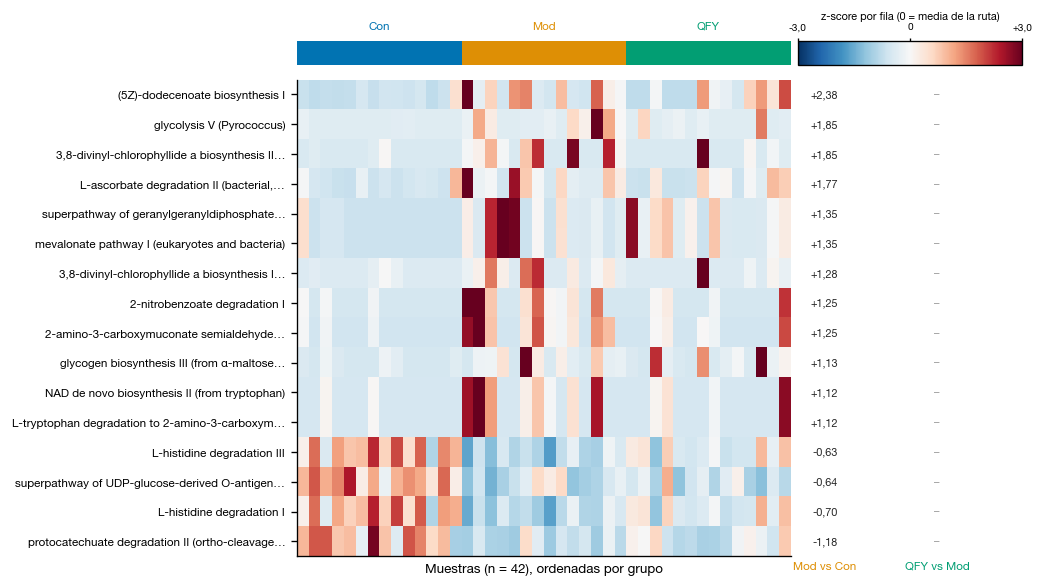

In [19]:
# --- Figura 7: heatmap de las rutas predichas (PICRUSt2 + ANCOM-BC2, P10) ---
import html
from matplotlib.colors import ListedColormap, TwoSlopeNorm

# Filas: las significativas Y robustas en cualquiera de los dos contrastes. Si
# quedan muy pocas, se cae a las de mayor efecto entre las significativas.
sig7 = da_r[da_r.q < 0.05]
rob7 = sig7[sig7.diff_robust.astype(bool)]
if len(rob7["ruta"].unique()) >= 8:
    rutas7, criterio = rob7, "q < 0,05 y robustas"
else:
    rutas7 = sig7.assign(o=sig7.lfc.abs()).sort_values("o", ascending=False).head(20)
    criterio = "20 de mayor efecto (q < 0,05)"

# se ordenan por el lfc del contraste del modelo, que es el que tiene mas senal
orden = (rutas7[rutas7.contraste == "Mod vs Con"].set_index("ruta")["lfc"]
         .reindex(rutas7["ruta"].unique()).fillna(0).sort_values(ascending=False))
RUT = list(orden.index)

MU = [m for g in GRUPOS for m in md_.index[md_.grupo == g]]      # muestras por grupo
Z  = ab_r.loc[RUT, MU]
Z  = Z.sub(Z.mean(axis=1), axis=0).div(Z.std(axis=1).replace(0, 1), axis=0)   # z por fila

fig7 = plt.figure(figsize=(7.8, 0.23 * len(RUT) + 1.9))
gs   = fig7.add_gridspec(2, 2, height_ratios=[0.5, 10], width_ratios=[2.2, 1],
                         hspace=0.06, wspace=0.02)

# --- banda de grupos, arriba del heatmap ---
axg = fig7.add_subplot(gs[0, 0])
gi  = [GRUPOS.index(md_.loc[m, "grupo"]) for m in MU]
axg.imshow([gi], aspect="auto", cmap=ListedColormap([PAL[g] for g in GRUPOS]),
           vmin=0, vmax=len(GRUPOS) - 1)
axg.set_xticks([]); axg.set_yticks([])
for s in axg.spines.values():
    s.set_visible(False)
for g in GRUPOS:                                    # nombre del grupo sobre su bloque
    xs = [i for i, m in enumerate(MU) if md_.loc[m, "grupo"] == g]
    axg.text(np.mean(xs), -0.9, g, ha="center", va="bottom", fontsize=7, color=PAL[g])

# --- heatmap ---
ax = fig7.add_subplot(gs[1, 0])
vm = float(np.nanpercentile(np.abs(Z.values), 98))
im = ax.imshow(Z.values, aspect="auto", cmap="RdBu_r",
               norm=TwoSlopeNorm(vcenter=0, vmin=-vm, vmax=vm))
ax.set_xticks([]); ax.set_yticks(range(len(RUT)))

def _etq7(r, n=46, minimo=34):
    d = desc_r.get(r)
    s = html.unescape(str(d)) if isinstance(d, str) else r
    if len(s) > n:
        cut = s[:n]
        corte = cut.rsplit(" ", 1)[0] if " " in cut else cut
        # OJO: cortar en el ultimo espacio puede dejar la etiqueta en nada
        # ("superpathway of...") cuando la palabra siguiente es larga. Si el corte
        # limpio queda demasiado corto, se corta duro y listo.
        s = (corte if len(corte) >= minimo else cut) + "\u2026"
    return s

# misma desambiguacion que en la Figura 6: dos rutas DISTINTAS pueden colapsar a
# la misma etiqueta al cortarlas (pasa con los nombres de MetaCyc).
lab7 = [_etq7(r) for r in RUT]
por_lab = {}
for l, r in zip(lab7, RUT):
    por_lab.setdefault(l, set()).add(r)
lab7 = [f"{l} ({r})" if len(por_lab[l]) > 1 else l for l, r in zip(lab7, RUT)]
ax.set_yticklabels(lab7)
ax.set_xlabel(f"Muestras (n = {len(MU)}), ordenadas por grupo")

# --- columnas de numeros a la derecha: un lfc por contraste ---
axn = fig7.add_subplot(gs[1, 1], sharey=ax)
axn.axis("off")
piv = da_r.pivot_table(index="ruta", columns="contraste", values="lfc")
pq  = da_r.pivot_table(index="ruta", columns="contraste", values="q")
pr  = da_r.pivot_table(index="ruta", columns="contraste", values="diff_robust", aggfunc="first")
for j, c in enumerate(["Mod vs Con", "QFY vs Mod"]):
    # OJO: el nombre del contraste va DEBAJO de su columna. Arriba no cabe: el eje
    # del heatmap esta invertido y el texto se mete en la barra de color.
    axn.text(0.12 + j * 0.5, len(RUT) - 0.35, c, fontsize=7, ha="center",
             va="top", color=COL_C[c], transform=axn.get_yaxis_transform())
    for i, r in enumerate(RUT):
        lfc = piv.get(c, {}).get(r, np.nan)
        q   = pq.get(c, {}).get(r, np.nan)
        if pd.isna(lfc):
            continue
        # solo se escribe el numero si el test dio significativo; si no, guion
        txt = "\u2013" if pd.isna(q) or q >= 0.05 else (
              f"{lfc:+.2f}".replace(".", ",") + ("" if bool(pr.get(c, {}).get(r, False)) else " \u2020"))
        axn.text(0.12 + j * 0.5, i, txt, fontsize=6.5, ha="center", va="center",
                 color="0.15" if txt != "\u2013" else "0.6",
                 transform=axn.get_yaxis_transform())

# --- barra de color, en el hueco de arriba a la derecha ---
cax = fig7.add_subplot(gs[0, 1])
cb  = fig7.colorbar(im, cax=cax, orientation="horizontal")
cb.set_label("z-score por fila (0 = media de la ruta)", fontsize=6.5, labelpad=2)
cb.ax.tick_params(labelsize=6, length=2)
cb.set_ticks([-vm, 0, vm]); cb.set_ticklabels([f"-{vm:.1f}".replace(".", ","), "0", f"+{vm:.1f}".replace(".", ",")])
cax.xaxis.set_ticks_position("top"); cax.xaxis.set_label_position("top")

guardar(fig7, "fig7_heatmap_rutas")
print("filas:", len(RUT), "| criterio:", criterio)
print("rutas sin lfc en un contraste (guion en la columna):",
      int(sum(pd.isna(pq.reindex(RUT).get("QFY vs Mod", pd.Series(dtype=float))))))
